* Denoising Images with Autoencoders

In [1]:
# Dataset Preparation: The CIFAR-10 images are normalized to [0, 1]. Random Gaussian noise is added to simulate "noisy" images.
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

 The CIFAR-10 images are normalized to [0, 1]. Random Gaussian noise is added to simulate "noisy" images.

In [2]:
(x_train, _), (x_test, _) = cifar10.load_data()
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
# Random noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

The encoder compresses the input into a latent representation.
The decoder reconstructs the clean image from the latent representation.

In [4]:
# Build the autoencoder
input_img = Input(shape=(32, 32, 3))

In [5]:
# Encoder
x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)


In [6]:
 # Decode
x = Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)

In [7]:
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

In [ ]:
# Train the autoencoder
autoencoder.fit(x_train_noisy, x_train, epochs=20, batch_size=128, shuffle=True, validation_data=(x_test_noisy, x_test))

Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 171s 432ms/step - loss: 0.5935 - val_loss: 0.5832
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 166s 425ms/step - loss: 0.5809 - val_loss: 0.5803
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 203s 429ms/step - loss: 0.5791 - val_loss: 0.5794
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 172s 439ms/step - loss: 0.5782 - val_loss: 0.5794
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 197s 426ms/step - loss: 0.5775 - val_loss: 0.5781
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 199s 420ms/step - loss: 0.5770 - val_loss: 0.5775
Epoch 7/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 209s 437ms/step - loss: 0.5766 - val_loss: 0.5779
Epoch 8/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 165s 423ms/step - loss: 0.5763 - val_loss: 0.5769
Epoch 9/20
353/391 ━━━━━━━━━━━━━━━━━━━━ 15s 404ms/step - loss: 0.5764

In [ ]:
# Evaluate on test data
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step


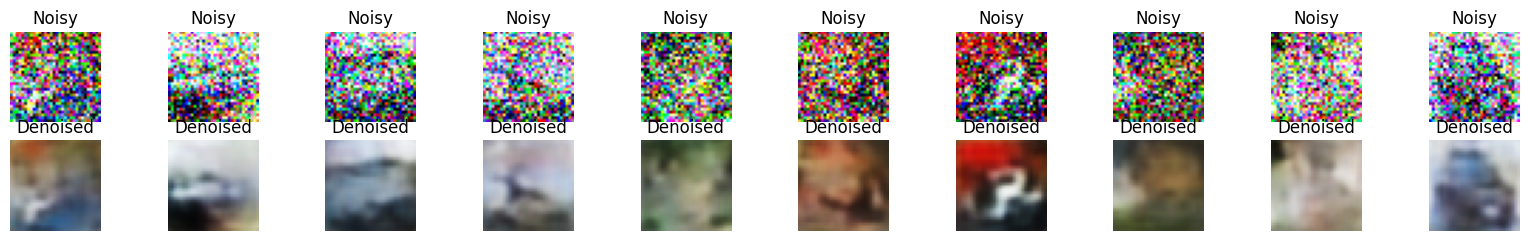

In [ ]:
# Visualize results
n = 10  # number of examples to display
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original noisy
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test_noisy[i])
    plt.title("Noisy")
    plt.axis('off')
    # Reconstructed
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(decoded_imgs[i])
    plt.title("Denoised")
    plt.axis('off')
plt.show()